# Objetivo
* Estudar o modelo SVM e apresentar diferentes questões sobre o modelo
* Apresentar como o modelo faz a decisão de classes.

**Contextualização**

O SVM é um modelo que se apoia em dados de treino para utilizar de vetores de suporte. Este suporte é feito para criar a curva de decisão, uma função que cria uma linha (ou superfícies de alta dimensão) no meio dos dados. Para classificação a curva é calculado de forma a separar as classes, mantendo a maior parte dos dados fora da região entre a linha e o vetor de suporte. Para regressão, o objetivo é ter uma linha que abrange a maior parte dos dados dentro da região.

# Importando Bibliotecas e Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = load_breast_cancer()
data.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

# Visualização rápida dos dados

In [3]:
#Transformar os dados em DataFrame
dados = pd.DataFrame(data.data, columns=[data.feature_names])
dados['target'] = data.target
dados.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
dados.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
dados.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


# Organização do Modelo

In [ ]:
# Separar Treino e Teste
X_treino, X_teste, y_treino, y_teste = train_test_split(data.data, data.target, test_size = 0.3,  random_state= 123)

C:\Users\kauea\AppData\Local\Temp\ipykernel_8712\2556032758.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_treino, X_teste, y_treino, y_teste = train_test_split(dados.drop('target', axis = 1), dados['target'], test_size = 0.3,  random_state= 123)


In [7]:
# 3. Normalizar
scaler = StandardScaler()
X_treino_escala = scaler.fit_transform(X_treino)
X_teste_escala = scaler.transform(X_teste)

# 4. Reduzir a 2D com PCA (só para visualização)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_treino_escala)
X_test_2d = pca.transform(X_teste_escala)

In [8]:
pca.explained_variance_ratio_

array([0.43987931, 0.19485149])

Modelo:
Kernal = RBF significa que usaremos a função RBF para o truque de Kernall.
C == 0.5 define um numero para a distância entre margem e linha de decisão
gamma = 'scale' define qual valor de gamma para o RBG

In [9]:
svm = SVC(kernel = 'rbf', C = 1, gamma = 'scale')
svm_linear = SVC(kernel = 'linear', C = 1, gamma = 'scale')
svm.fit(X_train_2d, y_treino)
svm_linear.fit(X_train_2d, y_treino)

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
#funcao acurácia
def acuracia(model):
  y_pred = model.predict(X_test_2d)
  acc = accuracy_score(y_teste, y_pred)
  print(acc)

In [11]:
acuracia(svm)
acuracia(svm_linear)

0.9590643274853801
0.9649122807017544


# Visualizando como o modelo funciona

In [12]:
#Função para visualizar diferentes modelos SVM
def plot_svc_decision_function_support(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""


    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    fig, axes = plt.subplots(1, 1, figsize=(10, 6))

  # --- Gráfico 1: Fronteira de decisão ---
    ax = axes
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    scatter = ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
              s=120, facecolors='none', edgecolors='black', linewidths=1.5,
              label='Support Vectors')
    ax.set_title(f'Fronteira de decisão SVM (RBF)\nPCA ')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    handles, _ = scatter.legend_elements()
    ax.legend(handles + [plt.Line2D([0], [0], marker='o', color='w',
              markeredgecolor='black', markerfacecolor='none', markersize=10)],
              ['Maligno (0)', 'Benigno (1)', 'Support Vectors'], loc='best')
    plt.show()

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


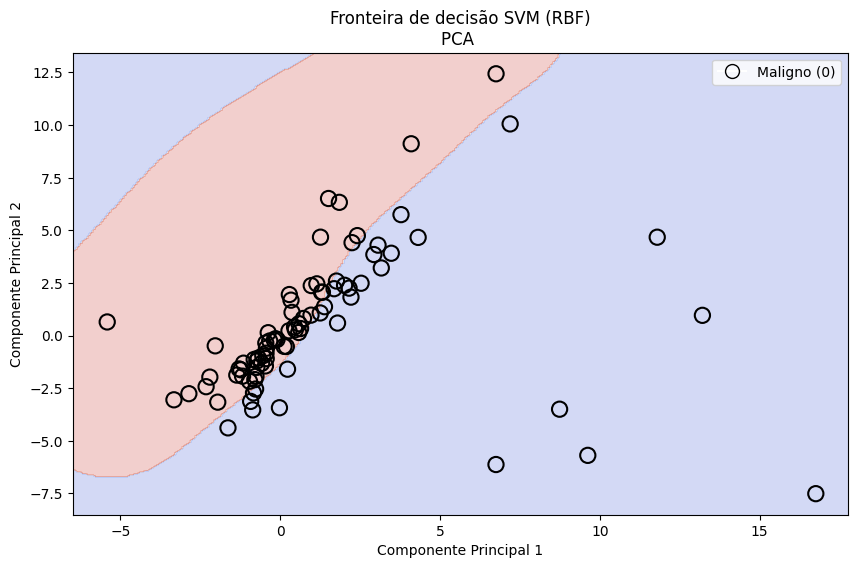

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


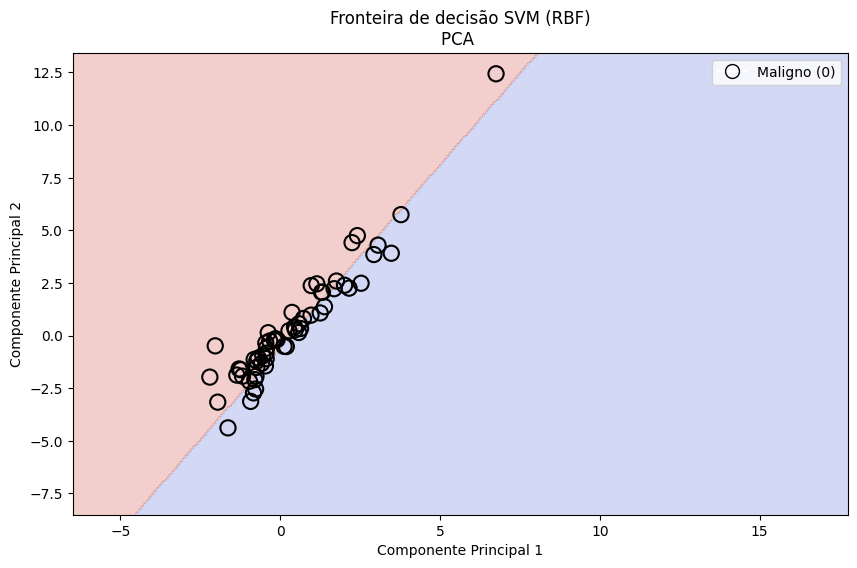

In [13]:
plot_svc_decision_function_support(svm)
plot_svc_decision_function_support(svm_linear)

In [14]:
def plot_svc_decision_function(model, X, y, ax=None, plot_support=True,
                                titulo='Fronteira de decisão SVM (RBF)'):
    """
    Plota a fronteira de decisão de um SVC 2D, junto com:
      - os pontos de treino coloridos pelo target (y) -> mostra a separação real
      - os support vectors circulados em preto (opcional)

    Parâmetros
    ----------
    model : SVC já treinado (model.fit(X, y) precisa ter sido chamado antes)
    X : array (n_amostras, 2) -> as duas features usadas no treino (ex: PCA)
    y : array (n_amostras,)   -> os targets (0/1), usados para colorir os pontos
    ax : matplotlib Axes, opcional. Se None, cria uma figura nova.
    plot_support : bool -> se True, destaca os support vectors
    """
    # Cria a figura só se não recebeu um eixo pronto (corrige o bug do ax=None ignorado)
    criar_propria_fig = ax is None
    if criar_propria_fig:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # --- Grid de fundo para colorir as regiões de decisão ---
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')

    # --- Pontos de treino coloridos pelo TARGET (isso é o que faltava) ---
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                          edgecolors='k', s=40)

    # --- Support vectors circulados por cima ---
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=120, facecolors='none', edgecolors='black', linewidths=1.5)

    ax.set_title(titulo)
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')

    # --- Legenda: classes vêm do scatter colorido por y; SV é um handle manual ---
    handles, _ = scatter.legend_elements()
    labels = ['Maligno (0)', 'Benigno (1)']
    if plot_support:
        handles = handles + [plt.Line2D([0], [0], marker='o', color='w',
                    markeredgecolor='black', markerfacecolor='none', markersize=10)]
        labels = labels + ['Support Vectors']
    ax.legend(handles, labels, loc='best')

    if criar_propria_fig:
        plt.tight_layout()
        plt.show()

    return ax

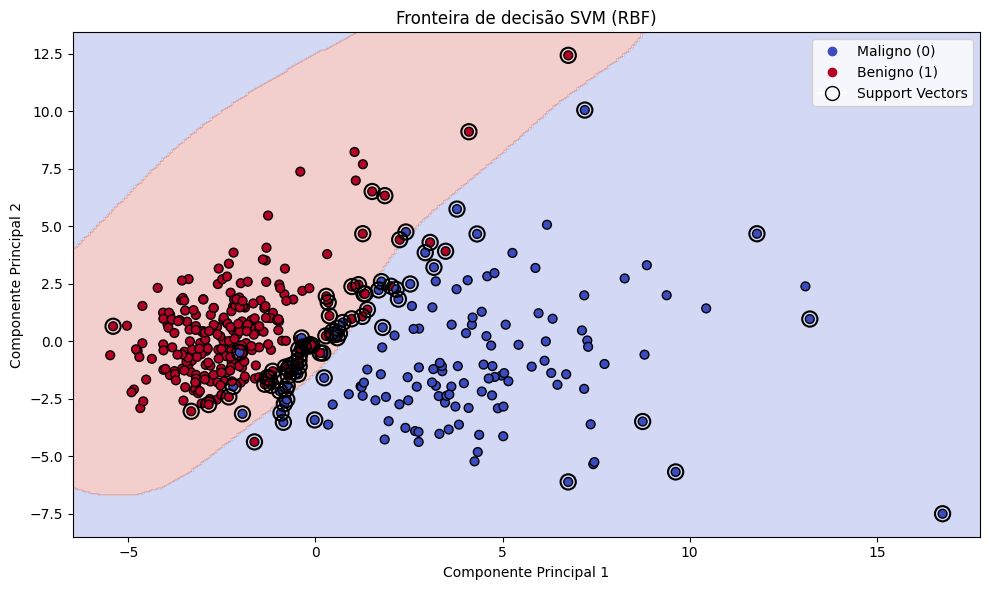

<Axes: title={'center': 'Fronteira de decisão SVM (RBF)'}, xlabel='Componente Principal 1', ylabel='Componente Principal 2'>

In [15]:
plot_svc_decision_function(svm, X_train_2d, y_treino)

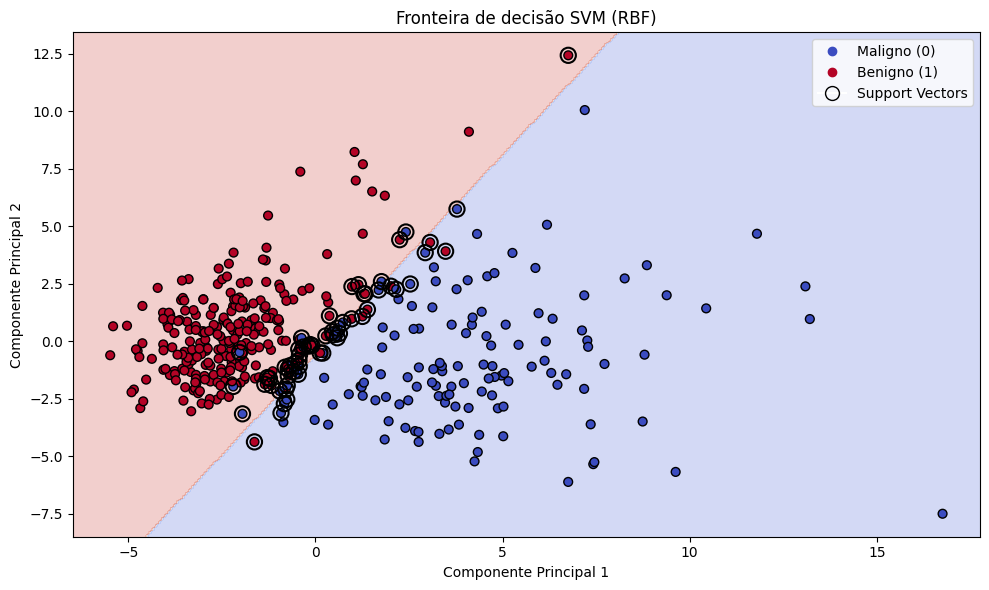

<Axes: title={'center': 'Fronteira de decisão SVM (RBF)'}, xlabel='Componente Principal 1', ylabel='Componente Principal 2'>

In [16]:
plot_svc_decision_function(svm_linear, X_train_2d, y_treino)

# Alterando parâmetro C no modelo linear

In [17]:
svm_linear_1 = SVC(kernel = 'linear', C = 1, gamma = 'scale')
svm_linear_2 = SVC(kernel = 'linear', C = 0.001, gamma = 'scale')
svm_linear_1.fit(X_train_2d, y_treino)
svm_linear_2.fit(X_train_2d, y_treino)

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,0.001
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
acuracia(svm_linear_1)
acuracia(svm_linear_2)

0.9649122807017544
0.9181286549707602


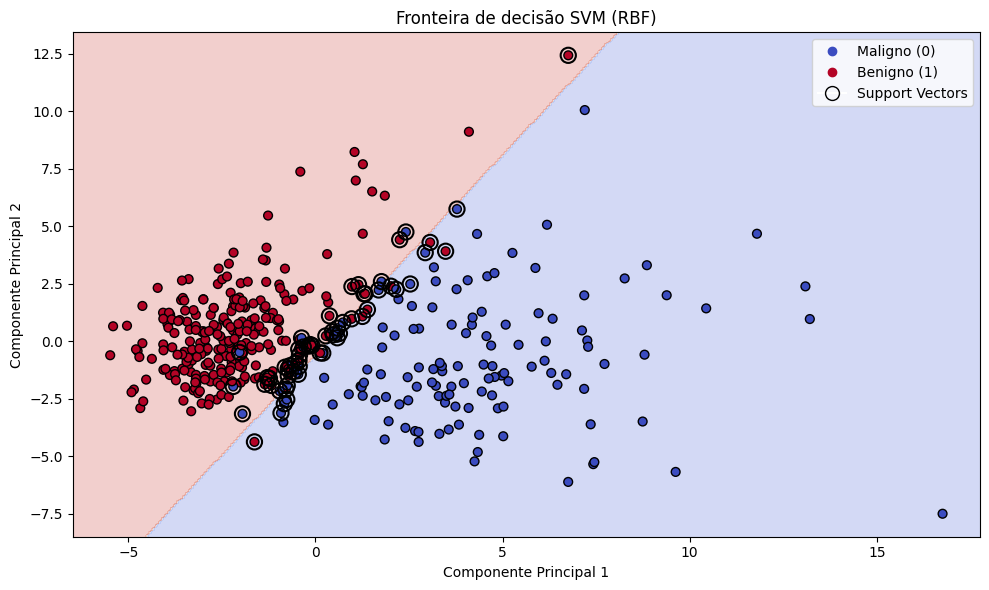

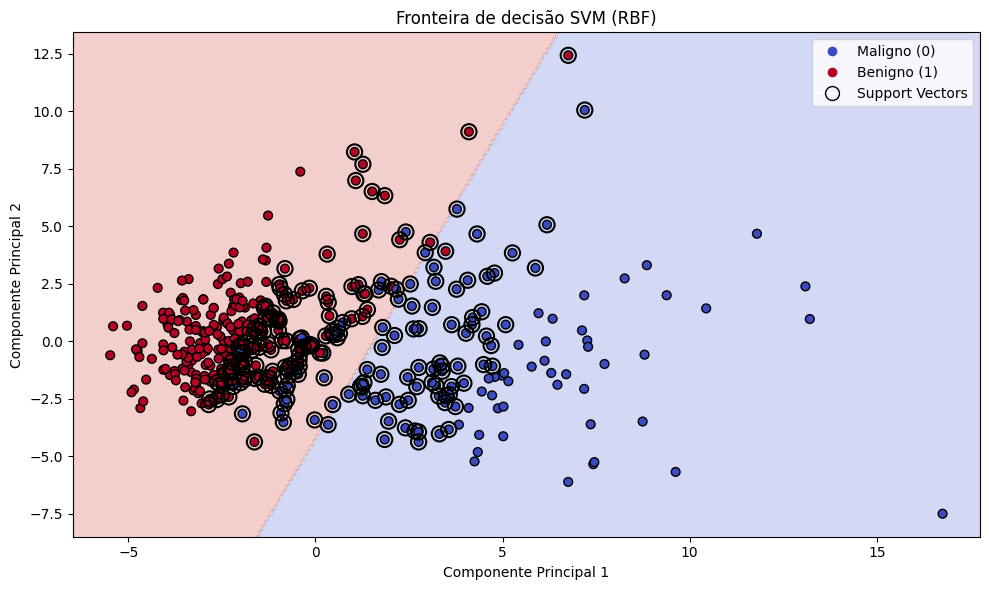

<Axes: title={'center': 'Fronteira de decisão SVM (RBF)'}, xlabel='Componente Principal 1', ylabel='Componente Principal 2'>

In [19]:
plot_svc_decision_function(svm_linear_1, X_train_2d, y_treino)
plot_svc_decision_function(svm_linear_2, X_train_2d, y_treino)

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


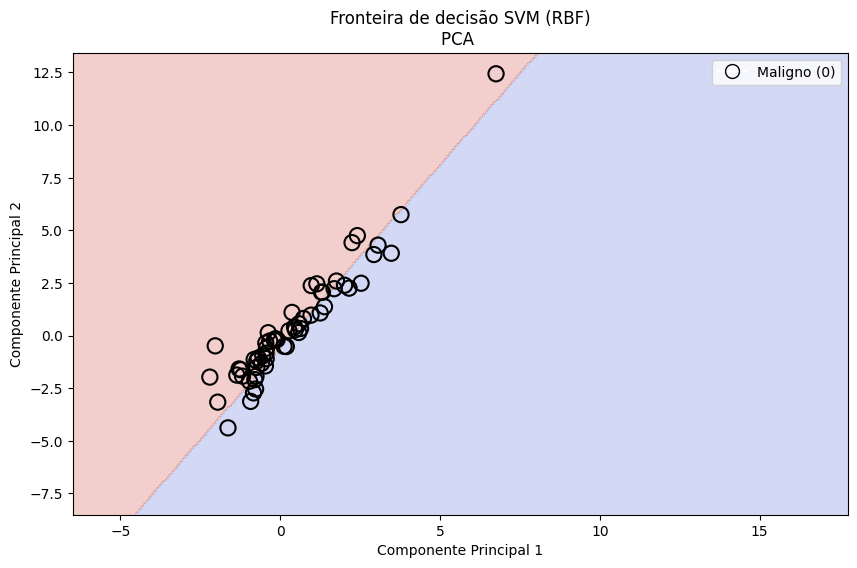

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


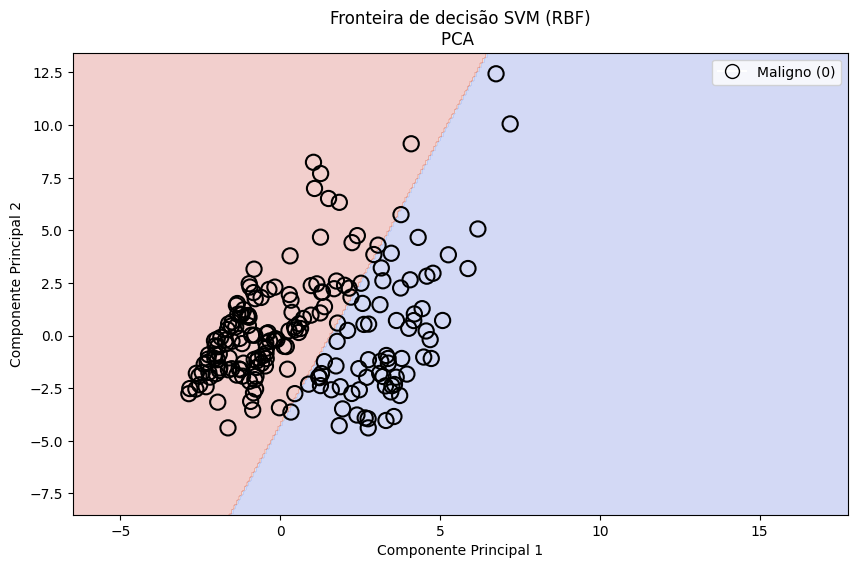

In [20]:
plot_svc_decision_function_support(svm_linear_1)
plot_svc_decision_function_support(svm_linear_2)

In [21]:
from matplotlib.animation import FuncAnimation

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A 

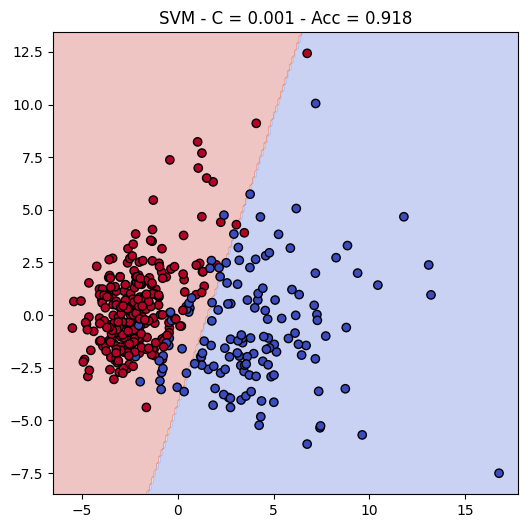

In [22]:

# supondo X com 2 colunas e y binário/multiclasse
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

C_values = np.linspace(0.001, 0.1, 100)

fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    C = C_values[frame]
    model = SVC(kernel="linear", C=C).fit(X_train_2d, y_treino)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_treino.values, cmap="coolwarm", edgecolors="k")
    ax.set_title(f"SVM - C = {C:.3f} - Acc = {accuracy_score(y_teste, model.predict(X_test_2d)):.3f}")
    return ax,

anim = FuncAnimation(fig, update, frames=len(C_values), interval=300)
anim.save("svm_c_animation.gif", writer="pillow")  # ou plt.show() no notebook


## Animação 3D

In [23]:
# 3. Normalizar
scaler = StandardScaler()
X_treino_escala = scaler.fit_transform(X_treino)
X_teste_escala = scaler.transform(X_teste)

# 4. Reduzir a 3D com PCA (só para visualização)
pca = PCA(n_components=3)
X_train_3d = pca.fit_transform(X_treino_escala)
X_test_3d = pca.transform(X_teste_escala)

c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kauea\anaconda3\envs\ambiente_atualizado\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A 

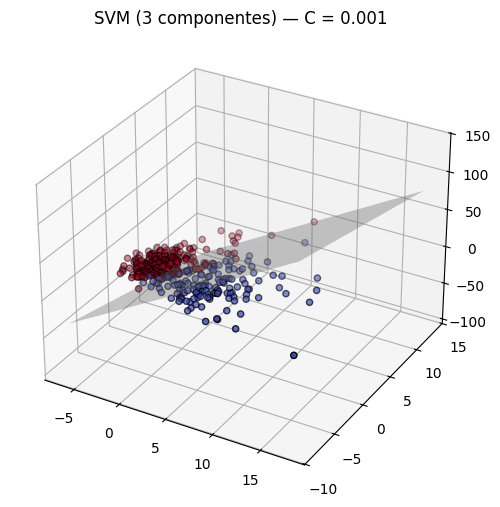

In [ ]:

# supondo X com 2 colunas e y binário/multiclasse
x_min, x_max = X_train_3d[:, 0].min() - 1, X_train_3d[:, 0].max() + 1
y_min, y_max = X_train_3d[:, 1].min() - 1, X_train_3d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

C_values = np.linspace(0.001, 0.1, 100)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

def update(frame):
    ax.clear()
    C = C_values[frame]
    model = SVC(kernel="linear", C=C).fit(X_train_3d, y_treino)

    # pontos reais em 3D
    ax.scatter(X_train_3d[:, 0], X_train_3d[:, 1], X_train_3d[:, 2],
               c=y_treino.values, cmap="coolwarm", edgecolors="k")

    # plano de decisão: w0*x + w1*y + w2*z + b = 0  ->  z = -(w0*x + w1*y + b)/w2
    w = model.coef_[0]
    b = model.intercept_[0]
    zz = -(w[0]*xx + w[1]*yy + b) / w[2]

    ax.plot_surface(xx, yy, zz, alpha=0.4, color="gray")
    ax.set_title(f"SVM (3 componentes) — C = {C:.3f}")
    return ax,

anim = FuncAnimation(fig, update, frames=len(C_values), interval=300)
anim.save("../Outcomes/svm_c_animation_3d.gif", writer="pillow")


In [25]:
import warnings
import plotly.graph_objects as go
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


In [31]:
n_frames = 60
t = np.linspace(0, 1, n_frames)
p = 1
C_min, C_max = 0.001, 0.5
# C_values = C_min + (C_max - C_min) * (t ** p)
C_values = np.linspace(0.001, 0.05, 60)

x_min, x_max = X_train_3d[:, 0].min() - 1, X_train_3d[:, 0].max() + 1
y_min, y_max = X_train_3d[:, 1].min() - 1, X_train_3d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30), np.linspace(y_min, y_max, 30))

y_arr = np.ravel(y_treino.values)
cor_por_classe = np.where(y_arr == 0, "#2a78d6", "#eb6834")

angulos = np.linspace(0, 2 * np.pi, n_frames)
raio_camera = 1.3

frames = []
for i, C in enumerate(C_values):
    model = SVC(kernel="linear", C=C).fit(X_train_3d, y_treino)
    w = model.coef_[0]
    b = model.intercept_[0]
    zz = -(w[0] * xx + w[1] * yy + b) / w[2]
    acc = accuracy_score(y_teste, model.predict(X_test_3d))

    eye = dict(x=raio_camera * np.cos(angulos[i]),
               y=raio_camera * np.sin(angulos[i]),
               z=0.6)

    frames.append(go.Frame(
        data=[
            go.Scatter3d(x=X_train_3d[:, 0], y=X_train_3d[:, 1], z=X_train_3d[:, 2],
                          mode="markers",
                          marker=dict(size=4, color=cor_por_classe, line=dict(width=0.5, color="black"))),
            go.Surface(x=xx, y=yy, z=zz, opacity=0.4, colorscale="Greys", showscale=False)
        ],
        name=f"{C:.4f}",
        layout=go.Layout(
            title=f"SVM (3 componentes PCA)",
            scene_camera=dict(eye=eye)
        )
    ))

frame_duration = 90
transition_duration = 0
easing = "linear"

fig = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title=frames[0].layout.title,
        scene=dict(
            xaxis=dict(title = '', visible = True,showgrid=True,showticklabels=False, showbackground=False),
            yaxis=dict(title = '', visible = True,showgrid=True,showticklabels=False, showbackground=False),
            zaxis=dict( range=[X_train_3d[:, 2].min() - 1, X_train_3d[:, 2].max() + 1], 
                       ticks='', visible=True, showticklabels=False),
            camera=dict(eye=dict(x=raio_camera, y=0, z=0.9))
        ),
        # updatemenus=[{
        #     "type": "buttons",
        #     "buttons": [{
        #         "label": "▶ Play",
        #         "method": "animate",
        #         "args": [None, {
        #             "frame": {"duration": frame_duration, "redraw": True},
        #             "transition": {"duration": transition_duration, "easing": easing},
        #             "fromcurrent": True
        #         }]
        #     }]
        # }],
        # sliders=[{
        #     "steps": [
        #         {"args": [[f.name], {"frame": {"duration": frame_duration, "redraw": True},
        #                               "transition": {"duration": transition_duration, "easing": easing}}],
        #          "label": f.name, "method": "animate"}
        #         for f in frames
        #     ]
        # }]
    )
)

fig.show()


In [32]:
from PIL import Image
import io

imagens = []
for fr in frames:
    # cria uma figura "congelada" com os dados + layout daquele frame específico
    frame_fig = go.Figure(data=fr.data, layout=fig.layout)
    frame_fig.update_layout(fr.layout)  # aplica título e câmera daquele frame

    img_bytes = frame_fig.to_image(format="png", width=800, height=700, scale=2)
    imagens.append(Image.open(io.BytesIO(img_bytes)))

imagens[0].save(
    "svm_animation_plotly1.gif",
    save_all=True,
    append_images=imagens[1:],
    duration=frame_duration,  # mesmo valor (em ms) que você usa na animação interativa
    loop=0                     # 0 = repete pra sempre
)
